# ***Feature Engineering* Geoespacial: Distritos y Flujo Urbano en París**

## **1. Objetivo**

El objetivo de este notebook es enriquecer el dataset de pedidos de Glovo mediante la creación de variables geoespaciales capaces de capturar patrones urbanos y logísticos relevantes para la predicción del tiempo de entrega.

A partir de las coordenadas de recojo y entrega se generan variables relacionadas con:
- ubicación distrital,
- distancia al centro urbano,
- cruce entre París y periferia,
- dirección del flujo del pedido.

Estas variables buscan representar dinámicas reales de movilidad dentro de París y su área metropolitana.

## **2. Variables creadas**

Se construyen las siguientes variables:
- `distrito_pickup`:	Distrito de París donde se realiza el recojo.
- `distrito_delivery`:	Distrito de París donde se realiza la entrega.
- `dist_p_centro`:	Distancia (km) entre el pickup y el centro de París.
- `dist_d_centro`:	Distancia (km) entre el delivery y el centro de París.
- `cruza_periferico`:	Indica si el pedido cruza entre París y suburbios.
- `flujo`:	Dirección del desplazamiento respecto al centro urbano.

## **3. Motivación**

La logística urbana en París presenta características espaciales muy marcadas:
- fuerte centralización,
- diferencias de tráfico entre distritos,
- congestión variable,
- impacto del periférico parisino,
- distinta densidad comercial según zonas.

Por ello, variables espaciales pueden aportar señal predictiva importante al modelo de ETA.

## **4. Metodología**

El proceso completo de ingeniería de variables geoespaciales consta de tres etapas principales:
- Obtención de códigos postales mediante geocodificación inversa
- Generación de variables distritales
- Construcción de métricas espaciales y de flujo urbano

In [ ]:
import pandas as pd
import numpy as np
import requests
from tqdm.auto import tqdm
import os

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

In [ ]:
df = pd.read_csv('glovo_ops_data_final.csv')
df_mod = df.copy()

### **4.1 Configuración general**

Se define como referencia el centro aproximado de París:

In [ ]:
CENTRO_PARIS = (48.8566, 2.3522)

Estas coordenadas corresponden aproximadamente a la zona de Notre-Dame y se utilizan para calcular distancias geodésicas respecto al centro urbano.

También se implementa la función `haversine_distance()`, que permite calcular distancias reales sobre la superficie terrestre utilizando la fórmula de Haversine.

In [ ]:
tqdm.pandas()

def haversine_distance(lat1, lon1, lat2, lon2):
    """Cálculo de distancia geodésica vectorizada."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

### **4.2 Obtención de códigos postales mediante geocodificación inversa**

Para identificar distritos y zonas urbanas se utiliza una API pública francesa. La API recibe coordenadas geográficas (lat, lon) y devuelve el código postal asociado.

In [ ]:
def get_api_postcode(lat, lon):
    """Consulta la API de Francia para obtener el CP crudo."""
    url = f"https://api-adresse.data.gouv.fr/reverse/?lon={lon}&lat={lat}"
    try:
        response = requests.get(url, timeout=3)
        return response.json()['features'][0]['properties']['postcode']
    except:
        return np.nan

def clasificar_cp(postcode):
    """Extrae distrito y zona para lógica interna."""
    if pd.isna(postcode) or str(postcode).lower() == 'nan':
        return np.nan, "Desconocido"

    pc_str = str(postcode).strip()
    dept = pc_str[:2]

    if dept == '75':
        try:
            distrito = int(pc_str[-2:])
            zona = "París Centro"
        except:
            distrito, zona = 0, "París Error"
    else:
        distrito, zona = 0, "Banlieue"

    return distrito, zona

# EJECUCIÓN

# A. Extraer códigos postales Únicos (Optimización de API)
print("📡 Paso 1: Consultando API de coordenadas únicas...")
coords = pd.concat([
    df_mod[['pickup_latitude', 'pickup_longitude']].rename(columns={'pickup_latitude':'lat', 'pickup_longitude':'lon'}),
    df_mod[['delivery_latitude', 'delivery_longitude']].rename(columns={'delivery_latitude':'lat', 'delivery_longitude':'lon'})
]).round(3).drop_duplicates()

# Construcción del diccionario geográfico
coords['cp_raw'] = coords.progress_apply(lambda x: get_api_postcode(x['lat'], x['lon']), axis=1)
geo_dict = coords.set_index(['lat', 'lon'])['cp_raw'].to_dict()

# B. Mapear y clasificar
print("\n🏷️ Paso 2: Procesando Distritos y Zonas...")
for prefix in ['pickup', 'delivery']:
    # Mapeo temporal del CP
    cp_col = f'tmp_cp_{prefix}'
    df_mod[cp_col] = df_mod.apply(lambda x: geo_dict.get((round(x[f'{prefix}_latitude'], 3), round(x[f'{prefix}_longitude'], 3))), axis=1)

    # Extraer variables (Distrito se queda, Zona es temporal)
    res = df_mod[cp_col].apply(lambda x: pd.Series(clasificar_cp(x)))
    df_mod[[f'distrito_{prefix}', f'tmp_zona_{prefix}']] = res

# C. Cálculos Espaciales
print("\n📏 Paso 3: Calculando métricas de distancia y flujo...")
df_mod['dist_p_centro'] = haversine_distance(df_mod['pickup_latitude'], df_mod['pickup_longitude'], *CENTRO_PARIS)
df_mod['dist_d_centro'] = haversine_distance(df_mod['delivery_latitude'], df_mod['delivery_longitude'], *CENTRO_PARIS)

# Variable de interacción: ¿Cruza el periférico?
df_mod['cruza_periferico'] = (df_mod['tmp_zona_pickup'] != df_mod['tmp_zona_delivery']).astype(int)

# Dirección del flujo (Umbral de 300m para evitar ruido)
diff_dist = df_mod['dist_p_centro'] - df_mod['dist_d_centro']
df_mod['flujo'] = np.where(diff_dist > 0.3, 'Centrípeto',
                  np.where(diff_dist < -0.3, 'Centrífugo', 'Lateral'))

# LIMPIEZA DE COLUMNAS TEMPORALES
# Eliminamos solo las variables de "andamiaje", manteniendo el resto original
cols_to_drop = [c for c in df_mod.columns if c.startswith('tmp_')]
df_mod.drop(columns=cols_to_drop, inplace=True)

print(f"\n✅ Proceso completado. Se han añadido 6 variables nuevas a las {len(df_mod.columns)-6} existentes.")

📡 Paso 1: Consultando API de coordenadas únicas...


  0%|          | 0/15010 [00:00<?, ?it/s]


🏷️ Paso 2: Procesando Distritos y Zonas...

📏 Paso 3: Calculando métricas de distancia y flujo...

✅ Proceso completado. Se han añadido 6 variables nuevas a las 21 existentes.


## **5. Resultados y análisis exploratorio**

In [ ]:
df_mod.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_longitude,delivery_latitude,delivery_longitude,saturation,distrito_pickup,distrito_delivery,dist_p_centro,dist_d_centro,cruza_periferico,flujo
0,32.0,700734,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2.275441,48.855068,2.283378,66,16.0,16.0,5.637138,5.038016,0,Centrípeto
1,29.0,1648235,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2.304495,48.867017,2.292787,40,8.0,16.0,3.866667,4.497923,0,Centrífugo
2,292.0,13527080,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2.360776,48.866713,2.364773,29,4.0,11.0,0.640054,1.452745,0,Centrífugo
3,743.0,275173,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2.285694,48.884335,2.259989,54,16.0,0.0,4.877379,7.415955,1,Centrífugo
4,838.0,1105241,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2.361240,48.868087,2.371050,77,3.0,11.0,1.005934,1.879541,0,Centrífugo


In [ ]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     63646 non-null  float64
 1   customer_id                  63646 non-null  int64  
 2   courier_id                   63646 non-null  float64
 3   store_address_id             52018 non-null  float64
 4   store_name                   52018 non-null  object 
 5   vertical                     63646 non-null  object 
 6   gtv                          63646 non-null  float64
 7   delivery_fee                 63646 non-null  float64
 8   description                  63614 non-null  object 
 9   activation_time_local        63646 non-null  object 
 10  courier_started_order_local  63642 non-null  object 
 11  pickup_time_local            63646 non-null  object 
 12  delivery_time_local          63646 non-null  object 
 13  tranport_type   

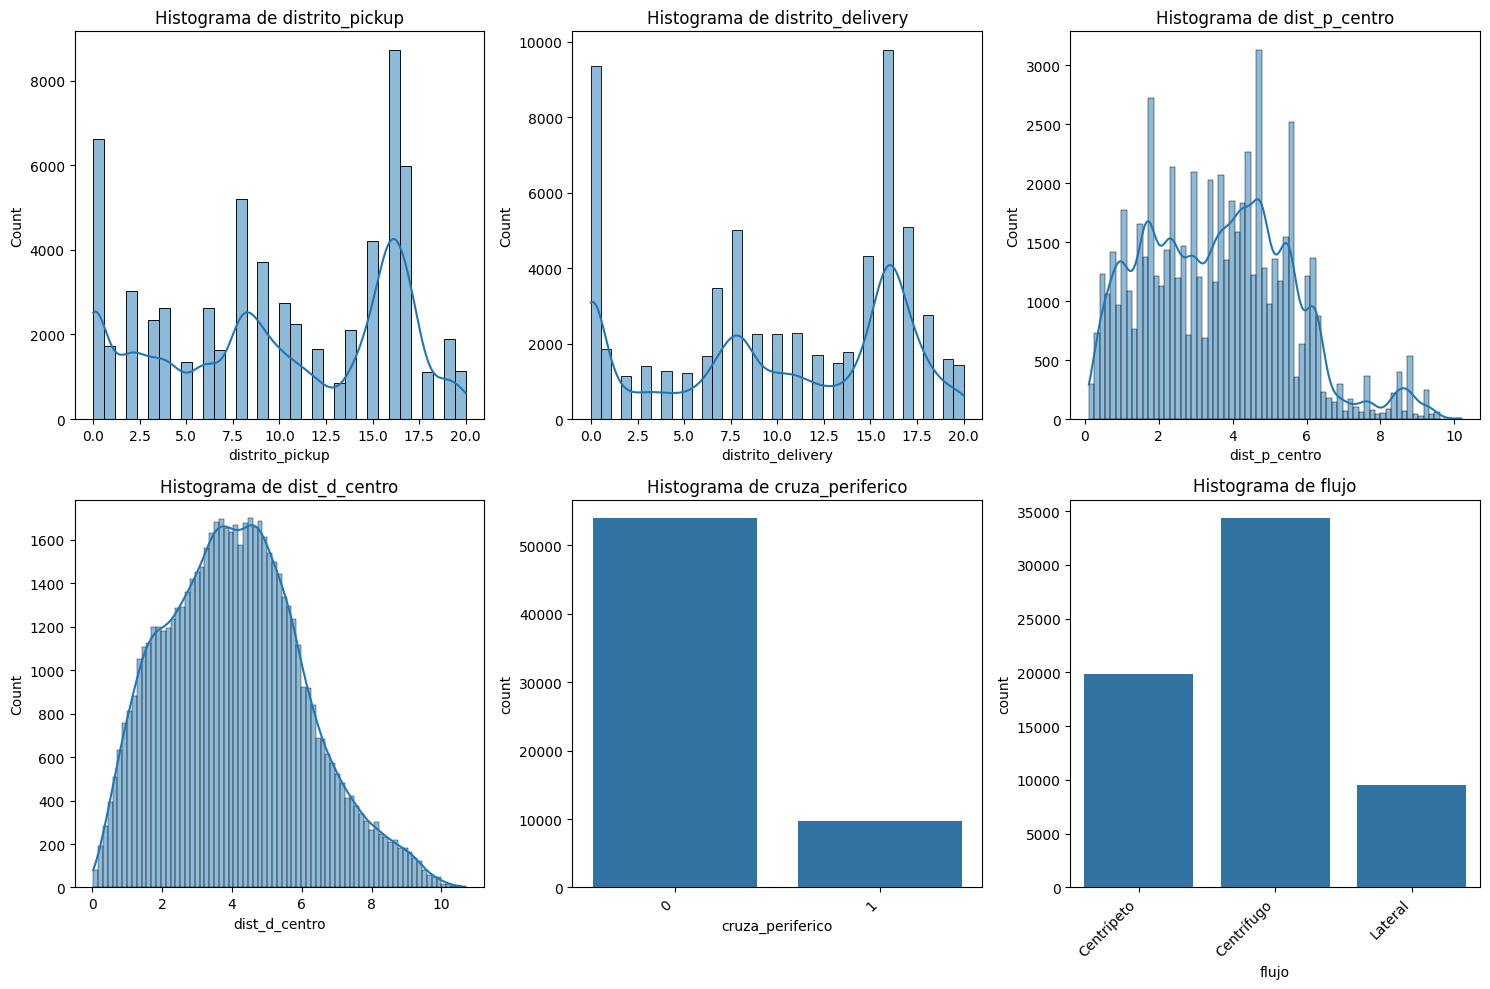

In [ ]:
columns_to_plot = ['distrito_pickup', 'distrito_delivery', 'dist_p_centro', 'dist_d_centro', 'cruza_periferico', 'flujo']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_plot):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    if df_mod[col].dtype == 'object' or col == 'cruza_periferico': # Handle categorical/discrete variables differently
        sns.countplot(data=df_mod, x=col)
        plt.title(f'Histograma de {col}')
        plt.xticks(rotation=45, ha='right')
    else:
        sns.histplot(df_mod[col].dropna(), kde=True)
        plt.title(f'Histograma de {col}')

plt.tight_layout()
plt.show()

In [ ]:
# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path to the CSV file
file_path = '/content/drive/MyDrive/Reto_IA/Distritos/distritos.csv'


Mounted at /content/drive
CSV '/content/drive/MyDrive/Reto_IA/Distritos/distritos.csv' cargado exitosamente.
   order_id  customer_id  courier_id  store_address_id store_name  \
0      32.0       700734       441.0           10887.0  Pharmacie   
1      29.0      1648235       239.0            3705.0  Starbucks   
2     292.0     13527080       351.0            1035.0  Starbucks   
3     743.0       275173       391.0               NaN        NaN   
4     838.0      1105241       263.0           51106.0   Franprix   

            vertical    gtv  delivery_fee  \
0     WALL - Partner  19.97           4.9   
1  WALL - NonPartner  10.50           4.9   
2  WALL - NonPartner  10.35           4.9   
3            COURIER   6.60           6.6   
4     WALL - Partner  13.10           3.9   

                                         description    activation_time_local  \
0  1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...  2019-10-01 09:21:34.000   
1  1 x Caffe Latte -  Tall,  Espresso Roast

In [ ]:
df_distritos.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_longitude,delivery_latitude,delivery_longitude,saturation,distrito_pickup,distrito_delivery,dist_p_centro,dist_d_centro,cruza_periferico,flujo
0,32.0,700734,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2.275441,48.855068,2.283378,66,16.0,16.0,5.637138,5.038016,0,Centrípeto
1,29.0,1648235,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2.304495,48.867017,2.292787,40,8.0,16.0,3.866667,4.497923,0,Centrífugo
2,292.0,13527080,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2.360776,48.866713,2.364773,29,4.0,11.0,0.640054,1.452745,0,Centrífugo
3,743.0,275173,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2.285694,48.884335,2.259989,54,16.0,0.0,4.877379,7.415955,1,Centrífugo
4,838.0,1105241,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2.361240,48.868087,2.371050,77,3.0,11.0,1.005934,1.879541,0,Centrífugo


**Distribución de distritos**

Los histogramas muestran una fuerte concentración de pedidos en ciertos distritos, especialmente:
- distrito 16,
- distrito 17,
- distrito 8,
- distrito 15.

Esto sugiere que la actividad logística no es homogénea dentro de París y que algunos distritos concentran una mayor densidad comercial y residencial.

Por otro lado, el valor 0 representa pedidos fuera de París intra-muros (*banlieue*). Se observa una presencia significativa de estos registros tanto en pickup como en delivery. Esto indica que una parte relevante de la operación involucra trayectos metropolitanos.

In [ ]:
print('Counts for distrito_pickup:')
print(df_distritos['distrito_pickup'].value_counts(dropna=False))
print('\nCounts for distrito_delivery:')
print(df_distritos['distrito_delivery'].value_counts(dropna=False))

Counts for distrito_pickup:
distrito_pickup
16.0    8734
0.0     6632
17.0    5997
8.0     5198
15.0    4207
9.0     3726
2.0     3032
10.0    2749
6.0     2621
4.0     2616
3.0     2345
11.0    2238
14.0    2115
19.0    1882
1.0     1716
12.0    1651
7.0     1626
5.0     1358
20.0    1128
18.0    1106
13.0     842
NaN      127
Name: count, dtype: int64

Counts for distrito_delivery:
distrito_delivery
16.0    9791
0.0     9370
17.0    5101
8.0     5002
15.0    4320
7.0     3470
18.0    2754
11.0    2277
9.0     2246
10.0    2245
1.0     1858
14.0    1781
12.0    1685
6.0     1670
19.0    1587
13.0    1492
20.0    1426
3.0     1395
4.0     1273
5.0     1208
2.0     1131
NaN      564
Name: count, dtype: int64


**Distancia al centro urbano**

Las variables `dist_p_centro` y `dist_d_centro`presentan distribuciones continuas con concentración entre 2 km y 6 km aproximadamente.

Esto sugiere que:
- gran parte de la actividad ocurre relativamente cerca del centro,
- existen trayectos periféricos más largos,
- la operación mantiene fuerte centralización urbana.

También se observa una ligera cola derecha asociada a pedidos más alejados.

**Cruce del periférico**

El análisis muestra que la mayoría de pedidos ocurren dentro de la misma zona urbana (París o periferia). Sin embargo, aproximadamente 1 de cada 6 pedidos requiere cruzar el periférico, lo cual puede representar trayectos más complejos desde el punto de vista logístico.

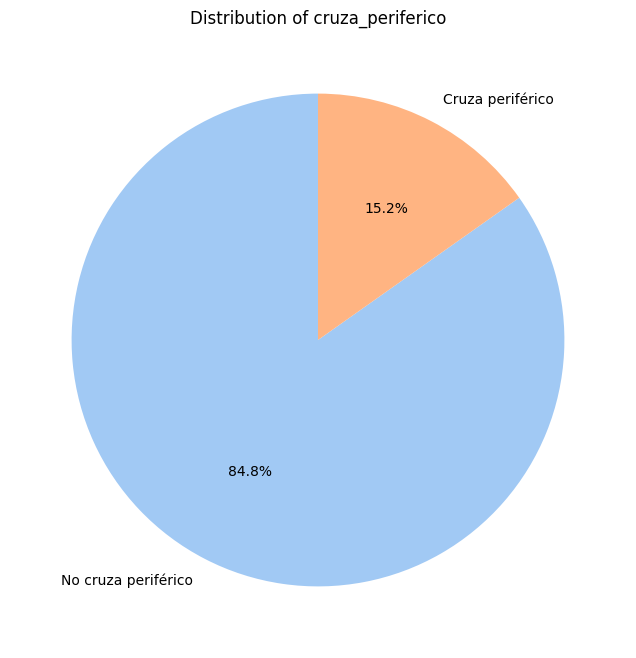

In [ ]:
# Calculate counts for cruza_periferico
cruza_periferico_counts = df_distritos['cruza_periferico'].value_counts(dropna=False)

# Define labels (0: No cruza, 1: Cruza)
labels = []
for index_val in cruza_periferico_counts.index:
    if pd.isna(index_val):
        labels.append('NaN')
    elif index_val == 0:
        labels.append('No cruza periférico')
    elif index_val == 1:
        labels.append('Cruza periférico')
    else:
        labels.append(str(index_val)) # Fallback for unexpected values

plt.figure(figsize=(8, 8))
plt.pie(cruza_periferico_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of cruza_periferico')
plt.ylabel('')
plt.show()

**Dirección del flujo urbano**

Predominan los trayectos centrífugos, es decir desde zonas más céntricas hacia zonas periféricas. Esto resulta consistente con patrones urbanos típicos donde comercios y restaurantes se concentran en áreas centrales y los clientes se distribuyen más ampliamente hacia zonas residenciales periféricas.

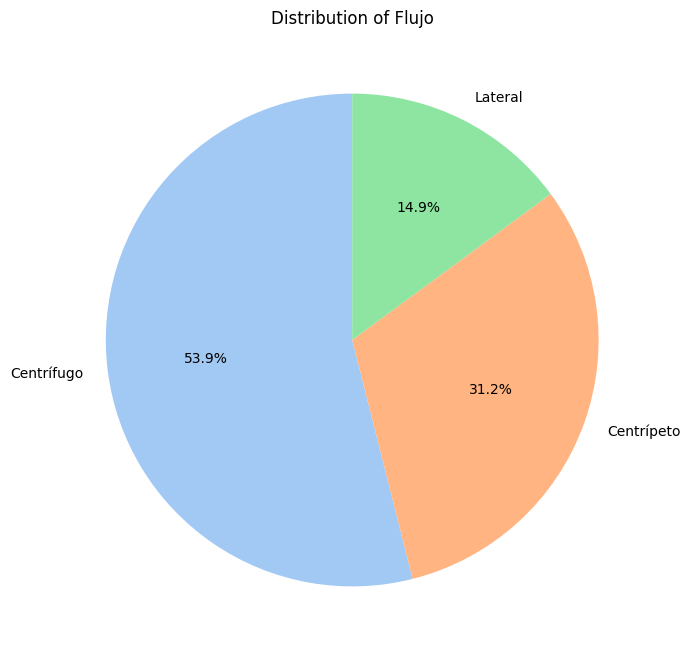

In [ ]:
flujo_counts = df_mod['flujo'].value_counts(dropna=False)

plt.figure(figsize=(8, 8))
plt.pie(flujo_counts, labels=flujo_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Flujo')
plt.ylabel('')
plt.show()

## **6. Obtención de códigos postales sin transformaciones**

Tras la transformación inicial de los códigos postales, se procedió a la reejecución del script para extraer y tratar la variable directamente. Este proceso permitió validar la integridad geográfica de la muestra, asegurando que los registros se limiten a París y su área metropolitana, identificados por los prefijos 7 y 9.

In [ ]:
# 1. CONFIGURACIÓN Y FUNCIONES
CENTRO_PARIS = (48.8566, 2.3522)
tqdm.pandas()

def haversine_distance(lat1, lon1, lat2, lon2):
    """Cálculo de distancia geodésica vectorizada."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

def get_api_postcode(lat, lon):
    """Consulta la API de Francia para obtener el CP de 5 dígitos."""
    url = f"https://api-adresse.data.gouv.fr/reverse/?lon={lon}&lat={lat}"
    try:
        response = requests.get(url, timeout=3)
        return response.json()['features'][0]['properties']['postcode']
    except:
        return np.nan

# 2. EJECUCIÓN
# A. Extraer códigos postales únicos (Optimización de API)
print("📡 Paso 1: Consultando API de coordenadas únicas...")
coords = pd.concat([
    df_mod[['pickup_latitude', 'pickup_longitude']].rename(columns={'pickup_latitude':'lat', 'pickup_longitude':'lon'}),
    df_mod[['delivery_latitude', 'delivery_longitude']].rename(columns={'delivery_latitude':'lat', 'delivery_longitude':'lon'})
]).round(3).drop_duplicates()

coords['cp_raw'] = coords.progress_apply(lambda x: get_api_postcode(x['lat'], x['lon']), axis=1)
geo_dict = coords.set_index(['lat', 'lon'])['cp_raw'].to_dict()

# B. Mapear el código postal directo
print("\n🏷️ Paso 2: Asignando Códigos Postales directos...")
for prefix in ['pickup', 'delivery']:
    # Creamos la columna con el CP de 5 dígitos (ej: 75008, 92100)
    df_mod[f'cp_{prefix}'] = df_mod.apply(
        lambda x: geo_dict.get((round(x[f'{prefix}_latitude'], 3), round(x[f'{prefix}_longitude'], 3))),
        axis=1
    )

# C. Cálculos espaciales y lógica de negocio
print("\n📏 Paso 3: Calculando métricas de distancia y flujo...")

# Distancias al centro
df_mod['dist_p_centro'] = haversine_distance(df_mod['pickup_latitude'], df_mod['pickup_longitude'], *CENTRO_PARIS)
df_mod['dist_d_centro'] = haversine_distance(df_mod['delivery_latitude'], df_mod['delivery_longitude'], *CENTRO_PARIS)

# Variable "cruza periférico": Comparamos si uno es París (75) y el otro no
def es_paris(cp):
    return str(cp).startswith('75') if pd.notna(cp) else False

df_mod['cruza_periferico'] = (
    df_mod['cp_pickup'].apply(es_paris) != df_mod['cp_delivery'].apply(es_paris)
).astype(int)

# Dirección del flujo
diff_dist = df_mod['dist_p_centro'] - df_mod['dist_d_centro']
df_mod['flujo'] = np.where(diff_dist > 0.3, 'Centrípeto',
                  np.where(diff_dist < -0.3, 'Centrífugo', 'Lateral'))

print(f"\n✅ Proceso completado. Columnas creadas: cp_pickup, cp_delivery, dist_p_centro, dist_d_centro, cruza_periferico, flujo.")

📡 Paso 1: Consultando API de coordenadas únicas...


  0%|          | 0/15010 [00:00<?, ?it/s]


🏷️ Paso 2: Asignando Códigos Postales directos...

📏 Paso 3: Calculando métricas de distancia y flujo...

✅ Proceso completado. Columnas creadas: cp_pickup, cp_delivery, dist_p_centro, dist_d_centro, cruza_periferico, flujo.


## **7. Calidad y completitud de datos**

Se revisa que los códigos postales solo inicien con 7 o 9, así como también revisar la candidad de NaNs.

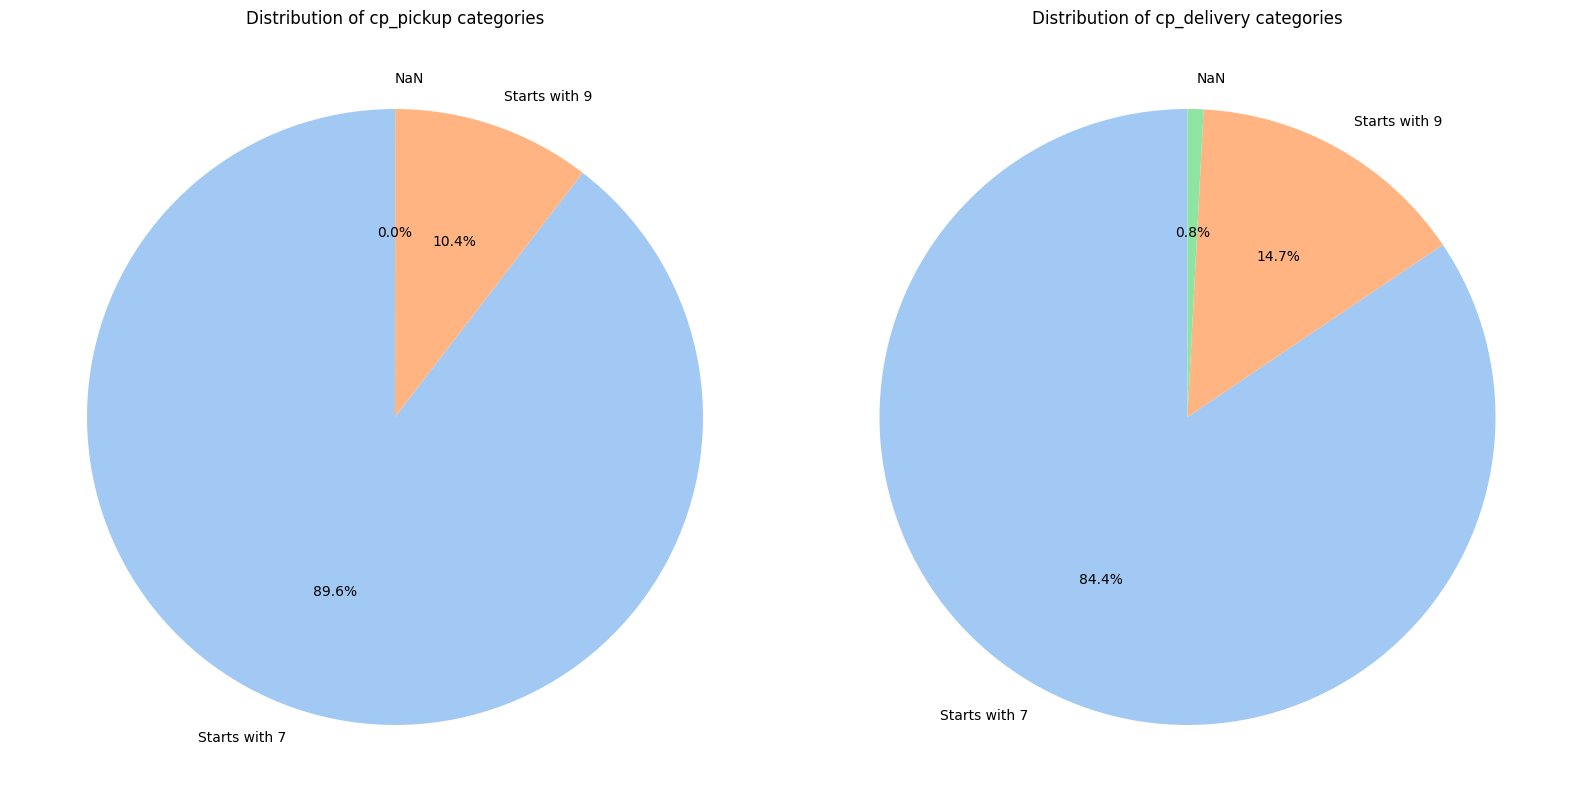

In [ ]:
def categorize_cp(cp_value):
    if pd.isna(cp_value):
        return 'NaN'
    cp_str = str(cp_value)
    if cp_str.startswith('9'):
        return 'Starts with 9'
    elif cp_str.startswith('7'):
        return 'Starts with 7'
    else:
        return 'Other'

# Apply categorization to both columns
df_mod['cp_pickup_cat'] = df_mod['cp_pickup'].apply(categorize_cp)
df_mod['cp_delivery_cat'] = df_mod['cp_delivery'].apply(categorize_cp)

# Calculate counts for each column separately
pickup_counts = df_mod['cp_pickup_cat'].value_counts()
delivery_counts = df_mod['cp_delivery_cat'].value_counts()

# Pie chart for cp_pickup
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.pie(pickup_counts, labels=pickup_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of cp_pickup categories')
plt.ylabel('')

# Pie chart for cp_delivery
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of cp_delivery categories')
plt.ylabel('')

plt.tight_layout()
plt.show()

df_mod.drop(columns=['cp_pickup_cat', 'cp_delivery_cat'], inplace=True, errors='ignore')

`cp_pickup` solo presenta 7 valores faltantes.

In [ ]:
df_mod.cp_pickup.isna().sum()

np.int64(7)

`cp_delivery` presenta 531 valores faltantes.

In [ ]:
df_mod.cp_delivery.isna().sum()

np.int64(531)

Esto representa una proporción muy baja respecto al total del dataset y probablemente se deba a coordenadas inválidas, fallos puntuales de API o
ubicaciones sin resolución postal exacta.

In [ ]:
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Reto_IA/Distritos'

os.makedirs(save_path, exist_ok=True)

file_name = 'distritos_v2.csv'
full_path = os.path.join(save_path, file_name)
df_mod.to_csv(full_path, index=False)

print(f"DataFrame 'df_mod' guardado exitosamente en: {full_path}")

Mounted at /content/drive
DataFrame 'df_mod' guardado exitosamente en: /content/drive/MyDrive/Reto_IA/Distritos/distritos_v2.csv
